In [51]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [52]:
#Define State
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    BMI: float
    label_bmi: str 

In [53]:
def Calculate_BMI(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['BMI'] = round(bmi, 2)

    return state

In [54]:
def Label_BMI(state: BMIState) -> BMIState:
    
    bmi = state['BMI']
    
    if bmi < 18.5:
        state["label_bmi"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["label_bmi"] = "Normal"
    elif 25 <= bmi < 30:
        state["label_bmi"] = "Overweight"
    else:
        state["label_bmi"] = "Obese"

    return state

In [55]:
#Define the graph
graph =  StateGraph(BMIState)

#add nodes
graph.add_node('Calculate_BMI', Calculate_BMI)
graph.add_node('Label_BMI', Label_BMI)

#add edges
graph.add_edge(START, 'Calculate_BMI')
graph.add_edge('Calculate_BMI', 'Label_BMI')
graph.add_edge('Label_BMI', END)

#Compile graph
worklfow = graph.compile()

In [58]:
#Execute the graph
intial_state = {'weight_kg':69.5, 'height_m':1.75}

final_state = worklfow.invoke(intial_state)

print(final_state)

{'weight_kg': 69.5, 'height_m': 1.75, 'BMI': 22.69, 'label_bmi': 'Normal'}


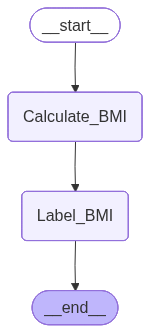

In [57]:
from IPython.display import Image
Image(worklfow.get_graph().draw_mermaid_png())